In [3]:
import os

# Download do dataset caso não exista localmente (Útil para Google Colab)
csv_file = 'timeseries_seed_101.csv'
if not os.path.exists(csv_file):
    print(f"Baixando {csv_file} do GitHub...")
    !wget -q https://raw.githubusercontent.com/rafaelwilliamm/glaukopis/main/timeseries_analysis/timeseries_seed_101.csv
    print("Download concluído.")
else:
    print(f"{csv_file} já existe localmente.")

timeseries_seed_101.csv já existe localmente.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaelwilliamm/glaukopis/blob/main/timeseries_analysis/Cap2_Graficos_Series_Temporais_Radar.ipynb)

# Capítulo 2 — Gráficos de Séries Temporais
### Aplicação ao Engajamento Radar BVR (Simulador Glaukopis)

**Referência**: Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. [otexts.com/fpp3/graphics.html](https://otexts.com/fpp3/graphics.html)

---

Este notebook aplica os conceitos do **Capítulo 2 do FPP3** a dados reais de simulação tática. O dataset provém do simulador **Glaukopis**, capturando um engajamento BVR (Beyond Visual Range) contra um **Su-27 Flanker** ao longo de 31.5 segundos a 10 Hz (317 amostras).

#### Mapeamento Capítulo → Dados Radar

| Conceito FPP3 | Variável Radar | Interpretação Física |
|---------------|----------------|----------------------|
| **Tendência** | `TGT_01_pos_x` | Trajetória cinemática determinística do alvo |
| **Ruído Branco (AWGN)** | `snr_db` | Degradação gaussiana do sinal pelo canal de propagação |
| **Variância Não-Estacionária** | `TGT_01_rcs_instantaneous` | Cintilação Swerling da assinatura radar |
| **Convergência Dinâmica** | `miss_distance_m` | Distância de engajamento (interceptador → alvo) |
| **Forçamento Não-Linear** | `g_force` | Aceleração centrípeta do míssil na guiagem PN |

#### Seções Cobertas
- §2.2 Time Plots
- §2.3 Padrões de Séries Temporais
- §2.6 Scatterplots
- §2.7 Lag Plots
- §2.8 Autocorrelação (ACF)
- §2.9 Ruído Branco

> **Nota**: As seções §2.4 (Seasonal Plots) e §2.5 (Subseries Plots) não se aplicam a este dataset, pois exigem sazonalidade calendárica (mensal, trimestral), ausente em um engajamento de 31.5 segundos.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# Configuração global de estilo
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de cores consistente para todos os gráficos
COLORS = {
    'trend': '#2ecc71',       # Verde — tendência/sinal puro
    'noise': '#9b59b6',       # Roxo — ruído/SNR
    'rcs': '#e74c3c',         # Vermelho — RCS instantâneo
    'rcs_mean': '#c0392b',    # Vermelho escuro — RCS médio
    'interceptor': '#e67e22', # Laranja — míssil
    'threshold': '#e74c3c',   # Vermelho — limiar
    'gforce': '#3498db',      # Azul — G-force
    'miss': '#1abc9c',        # Turquesa — miss distance
    'acf_bar': '#2c3e50',     # Cinza escuro — barras do ACF
}

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 0. Carregamento e Inspeção dos Dados

In [5]:
df = pd.read_csv('timeseries_seed_101.csv')

print(f'Dimensões: {df.shape[0]} amostras × {df.shape[1]} variáveis')
print(f'Intervalo temporal: {df["time"].min():.1f}s a {df["time"].max():.1f}s')
print(f'Taxa de amostragem: {1 / (df["time"].iloc[1] - df["time"].iloc[0]):.0f} Hz')
print(f'\nColunas disponíveis:')
for col in df.columns:
    print(f'  • {col} ({df[col].dtype})')

df.head(10)

Dimensões: 316 amostras × 19 variáveis
Intervalo temporal: 0.0s a 31.5s
Taxa de amostragem: 10 Hz

Colunas disponíveis:
  • time (float64)
  • random_seed (int64)
  • scenario_id (str)
  • TGT_01_pos_x (float64)
  • TGT_01_pos_y (float64)
  • TGT_01_pos_z (float64)
  • INTERCEPTOR_01_pos_x (float64)
  • INTERCEPTOR_01_pos_y (float64)
  • INTERCEPTOR_01_pos_z (float64)
  • snr_db (float64)
  • miss_distance_m (float64)
  • g_force (float64)
  • track_status (str)
  • missile_launched (bool)
  • TGT_01_rcs_instantaneous (float64)
  • TGT_01_rcs_mean (float64)
  • TGT_01_sigma_min (float64)
  • TGT_01_sigma_max (float64)
  • TGT_01_display_label (str)


,time,random_seed,scenario_id,TGT_01_pos_x,TGT_01_pos_y,TGT_01_pos_z,INTERCEPTOR_01_pos_x,INTERCEPTOR_01_pos_y,INTERCEPTOR_01_pos_z,snr_db,miss_distance_m,g_force,track_status,missile_launched,TGT_01_rcs_instantaneous,TGT_01_rcs_mean,TGT_01_sigma_min,TGT_01_sigma_max,TGT_01_display_label
0,0.0,101,SU27_01_43km_head-on,42960.0,2005.0,3998.0,0.00,0.00,0.00,-0.73,0.00,0.00,SEARCHING,False,2.44600,3.36685,3.0,15.0,Su-27 Flanker — σ=3–15 m²
1,0.1,101,SU27_01_43km_head-on,42920.0,2010.0,3996.0,0.00,0.00,0.00,-7.25,0.00,0.00,SEARCHING,False,0.30000,3.36753,3.0,15.0,Su-27 Flanker — σ=3–15 m²
2,0.2,101,SU27_01_43km_head-on,42880.0,2015.0,3994.0,0.00,0.00,0.00,15.02,0.00,0.00,TENTATIVE,False,3.89386,3.36821,3.0,15.0,Su-27 Flanker — σ=3–15 m²
3,0.3,101,SU27_01_43km_head-on,42840.0,2020.0,3992.0,0.00,0.00,0.00,-0.93,0.00,0.00,TENTATIVE,False,0.70964,3.36889,3.0,15.0,Su-27 Flanker — σ=3–15 m²
4,0.4,101,SU27_01_43km_head-on,42800.0,2025.0,3990.0,0.00,0.00,0.00,-6.97,0.00,0.00,TENTATIVE,False,1.46262,3.36957,3.0,15.0,Su-27 Flanker — σ=3–15 m²
5,0.5,101,SU27_01_43km_head-on,42760.0,2030.0,3988.0,0.00,0.00,0.00,16.32,0.00,0.00,TENTATIVE,False,5.18991,3.37025,3.0,15.0,Su-27 Flanker — σ=3–15 m²
6,0.6,101,SU27_01_43km_head-on,42720.0,2035.0,3986.0,99.48,4.50,9.14,15.62,0.00,0.00,CONFIRMED,True,4.40112,3.37093,3.0,15.0,Su-27 Flanker — σ=3–15 m²
7,0.7,101,SU27_01_43km_head-on,42680.0,2040.0,3984.0,198.96,8.99,18.28,-6.84,42853.79,0.00,CONFIRMED,True,0.50017,3.37162,3.0,15.0,Su-27 Flanker — σ=3–15 m²
8,0.8,101,SU27_01_43km_head-on,42640.0,2045.0,3982.0,298.43,13.58,27.45,21.63,42714.06,1.95,CONFIRMED,True,17.43630,3.37231,3.0,15.0,Su-27 Flanker — σ=3–15 m²
9,0.9,101,SU27_01_43km_head-on,42600.0,2050.0,3980.0,397.89,18.34,36.69,15.74,42574.33,1.85,CONFIRMED,True,4.47713,3.37300,3.0,15.0,Su-27 Flanker — σ=3–15 m²


In [6]:
# Estatísticas descritivas das variáveis numéricas principais
cols_analise = ['TGT_01_pos_x', 'snr_db', 'TGT_01_rcs_instantaneous',
                'TGT_01_rcs_mean', 'miss_distance_m', 'g_force']
df[cols_analise].describe().round(2)

,TGT_01_pos_x,snr_db,TGT_01_rcs_instantaneous,TGT_01_rcs_mean,miss_distance_m,g_force
count,316.00,316.00,316.00,316.00,316.00,316.00
mean,36660.13,12.10,3.63,3.52,20894.81,4.83
std,3654.40,10.20,3.27,0.10,12711.81,6.49
min,30400.00,-18.18,0.30,3.37,0.00,0.00
25%,33510.00,2.42,1.25,3.43,9898.64,1.85
50%,36660.00,16.05,2.63,3.50,20871.90,2.76
75%,39810.00,19.19,5.23,3.60,31855.41,4.79
max,42960.00,25.30,21.56,3.72,42853.79,30.00


### Dicionário de Variáveis

| Variável | Unidade | Descrição |
|----------|---------|----------|
| `time` | segundos | Índice temporal da simulação (Δt = 0.1s) |
| `TGT_01_pos_x` | metros | Posição real do Su-27 no eixo X (determinística, livre de ruído) |
| `TGT_01_pos_y`, `_z` | metros | Posição nos eixos Y e Z |
| `INTERCEPTOR_01_pos_x/y/z` | metros | Posição do míssil interceptador (guiagem proporcional) |
| `snr_db` | decibéis (dB) | Relação Sinal-Ruído instantânea (corrompida por AWGN) |
| `miss_distance_m` | metros | Distância instantânea entre interceptador e alvo |
| `g_force` | G | Aceleração do míssil (cresce na fase terminal) |
| `track_status` | categórica | Estado do rastreio: SEARCHING → TENTATIVE → CONFIRMED |
| `missile_launched` | booleano | Se o míssil já foi lançado |
| `TGT_01_rcs_instantaneous` | m² | RCS instantâneo (modelo de cintilação Swerling) |
| `TGT_01_rcs_mean` | m² | RCS médio suavizado (~3.3–3.7 m²) |
| `TGT_01_sigma_min/max` | m² | Limites do modelo Swerling (3.0–15.0 m²) |

---
## §2.2 — Time Plots (Gráficos Temporais)

> *"A time plot is a graph in which the observations are plotted against the time at which they were observed."* — FPP3, §2.2

O gráfico temporal é a ferramenta mais fundamental. Plotamos os valores observados (eixo Y) contra o tempo (eixo X), revelando padrões como **tendência**, **ruído** e **variância não-estacionária**.

### Gráfico 1 — Tendência Determinística: Posição Cinemática do Alvo

A posição `TGT_01_pos_x` representa a trajetória **pura** do Su-27, calculada pelo integrador RK4 sem qualquer ruído.
Este é o equivalente à **tendência linear** (trend) descrita no FPP3.

- O alvo avança de **~43.000 m** (distância inicial) até **~30.400 m** em 31.5 segundos.
- A trajetória é perfeitamente linear (velocidade constante ≈ 400 m/s).
- A linha do interceptador mostra a guiagem proporcional perseguindo o alvo.

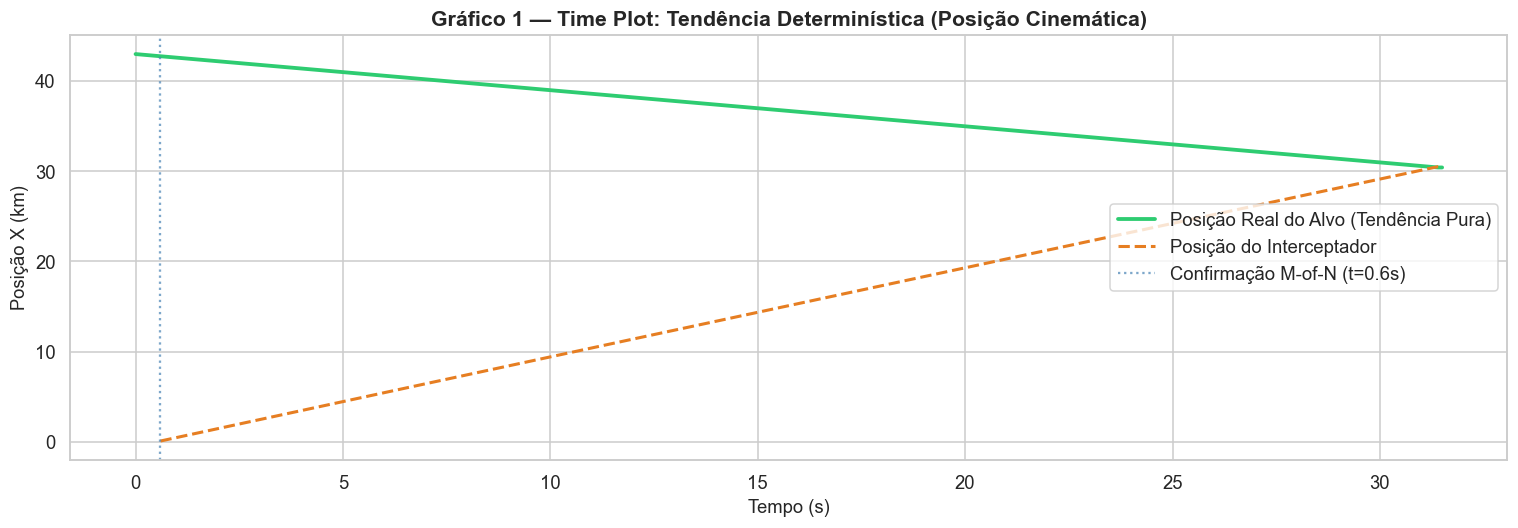

In [7]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 1 — Time Plot: Posição X do Alvo (Tendência Pura)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

# Tendência principal — posição do alvo
ax.plot(df['time'], df['TGT_01_pos_x'] / 1000,
        label='Posição Real do Alvo (Tendência Pura)',
        color=COLORS['trend'], linewidth=2.5)

# Míssil interceptador (quando lançado)
missile = df[df['missile_launched'] == True]
if not missile.empty:
    ax.plot(missile['time'], missile['INTERCEPTOR_01_pos_x'] / 1000,
            label='Posição do Interceptador',
            color=COLORS['interceptor'], linewidth=2, linestyle='--')

# Marcador de confirmação do rastreio
confirmed = df[df['track_status'] == 'CONFIRMED']
if not confirmed.empty:
    t_confirm = confirmed['time'].iloc[0]
    ax.axvline(t_confirm, color='steelblue', linestyle=':',
               label=f'Confirmação M-of-N (t={t_confirm:.1f}s)', alpha=0.7)

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Posição X (km)')
ax.set_title('Gráfico 1 — Time Plot: Tendência Determinística (Posição Cinemática)', fontweight='bold')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

### Gráfico 2 — Série Ruidosa: Signal-to-Noise Ratio (SNR)

O `snr_db` é o retorno eletromagnético do radar corrompido por **AWGN** (Additive White Gaussian Noise). Este é um exemplo clássico de série temporal com **ruído estocástico** sobreposto.

- A linha vermelha tracejada em **13 dB** é o limiar **CFAR** (Constant False Alarm Rate).
- Observações **abaixo do limiar** representam momentos em que o ruído sobrepõe o sinal ("fading").
- A série demonstra visualmente o conceito de **ruído branco** com variância aproximadamente constante.

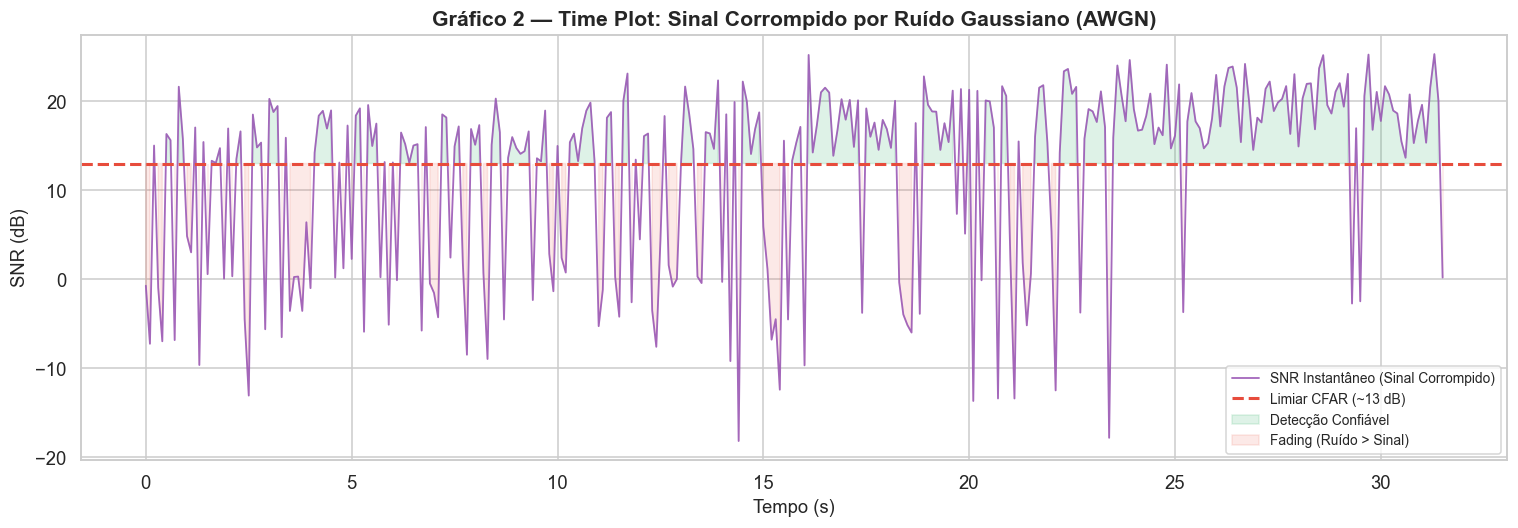

In [8]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 2 — Time Plot: SNR (Série Ruidosa / AWGN)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['time'], df['snr_db'],
        label='SNR Instantâneo (Sinal Corrompido)',
        color=COLORS['noise'], linewidth=1.2, alpha=0.9)

# Limiar CFAR
ax.axhline(y=13, color=COLORS['threshold'], linestyle='--',
           linewidth=2, label='Limiar CFAR (~13 dB)')

# Preenchimento: regiões de detecção vs fading
ax.fill_between(df['time'], df['snr_db'], 13,
                where=(df['snr_db'] > 13),
                color='#27ae60', alpha=0.15, label='Detecção Confiável')
ax.fill_between(df['time'], df['snr_db'], 13,
                where=(df['snr_db'] <= 13),
                color='#e74c3c', alpha=0.12, label='Fading (Ruído > Sinal)')

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Gráfico 2 — Time Plot: Sinal Corrompido por Ruído Gaussiano (AWGN)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Gráfico 3 — Variância Não-Estacionária: RCS com Cintilação Swerling

O `TGT_01_rcs_instantaneous` mostra a assinatura eletromagnética do Su-27 variando caoticamente devido ao modelo de **cintilação Swerling**.

- A **média** (`TGT_01_rcs_mean` ≈ 3.4 m²) permanece quase constante — uma tendência lenta.
- Os **picos** individuais podem chegar a 15+ m², demonstrando **alta variância não constante**.
- Os valores mínimos truncam em ~0.3 m² (limite físico do modelo).
- Este padrão justifica fisicamente a necessidade de **filtragem** (Alpha-Beta, Kalman).

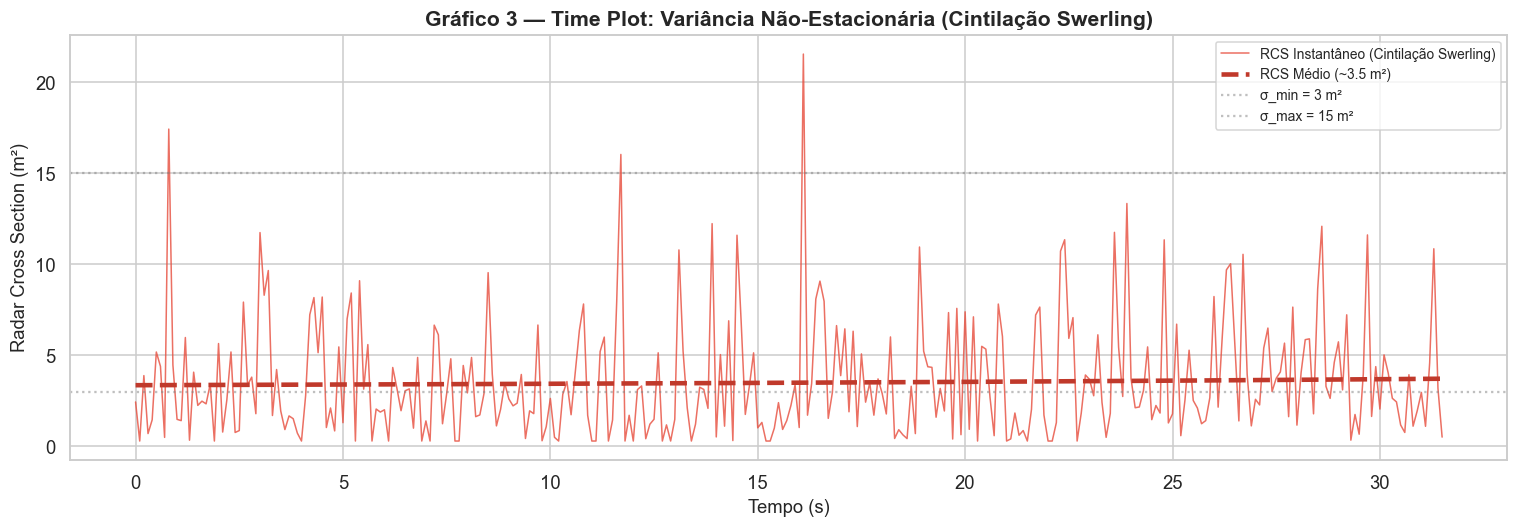

In [9]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 3 — Time Plot: RCS Instantâneo vs Médio (Cintilação)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['time'], df['TGT_01_rcs_instantaneous'],
        label='RCS Instantâneo (Cintilação Swerling)',
        color=COLORS['rcs'], linewidth=1.0, alpha=0.8)

ax.plot(df['time'], df['TGT_01_rcs_mean'],
        label=f'RCS Médio (~{df["TGT_01_rcs_mean"].mean():.1f} m²)',
        color=COLORS['rcs_mean'], linewidth=3, linestyle='--')

# Faixa Swerling
ax.axhline(y=df['TGT_01_sigma_min'].iloc[0], color='gray', linestyle=':',
           alpha=0.5, label=f'σ_min = {df["TGT_01_sigma_min"].iloc[0]:.0f} m²')
ax.axhline(y=df['TGT_01_sigma_max'].iloc[0], color='gray', linestyle=':',
           alpha=0.5, label=f'σ_max = {df["TGT_01_sigma_max"].iloc[0]:.0f} m²')

ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Radar Cross Section (m²)')
ax.set_title('Gráfico 3 — Time Plot: Variância Não-Estacionária (Cintilação Swerling)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---
## §2.3 — Padrões de Séries Temporais

> *"When we describe time series patterns, we use terms such as trend, seasonal and cyclic."* — FPP3, §2.3

O FPP3 identifica três padrões fundamentais:

| Padrão | Definição | No nosso dataset |
|--------|-----------|------------------|
| **Tendência** | Aumento/diminuição de longo prazo | `TGT_01_pos_x` — decaimento linear |
| **Sazonalidade** | Padrão fixo ligado ao calendário | ❌ Ausente (engajamento de 31.5s) |
| **Ciclo** | Flutuações não fixas, período variável | ❌ Ausente neste cenário |
| **Ruído** | Variação aleatória sem padrão | `snr_db` — AWGN puro |

O gráfico abaixo apresenta as 4 séries principais lado a lado para comparação visual.

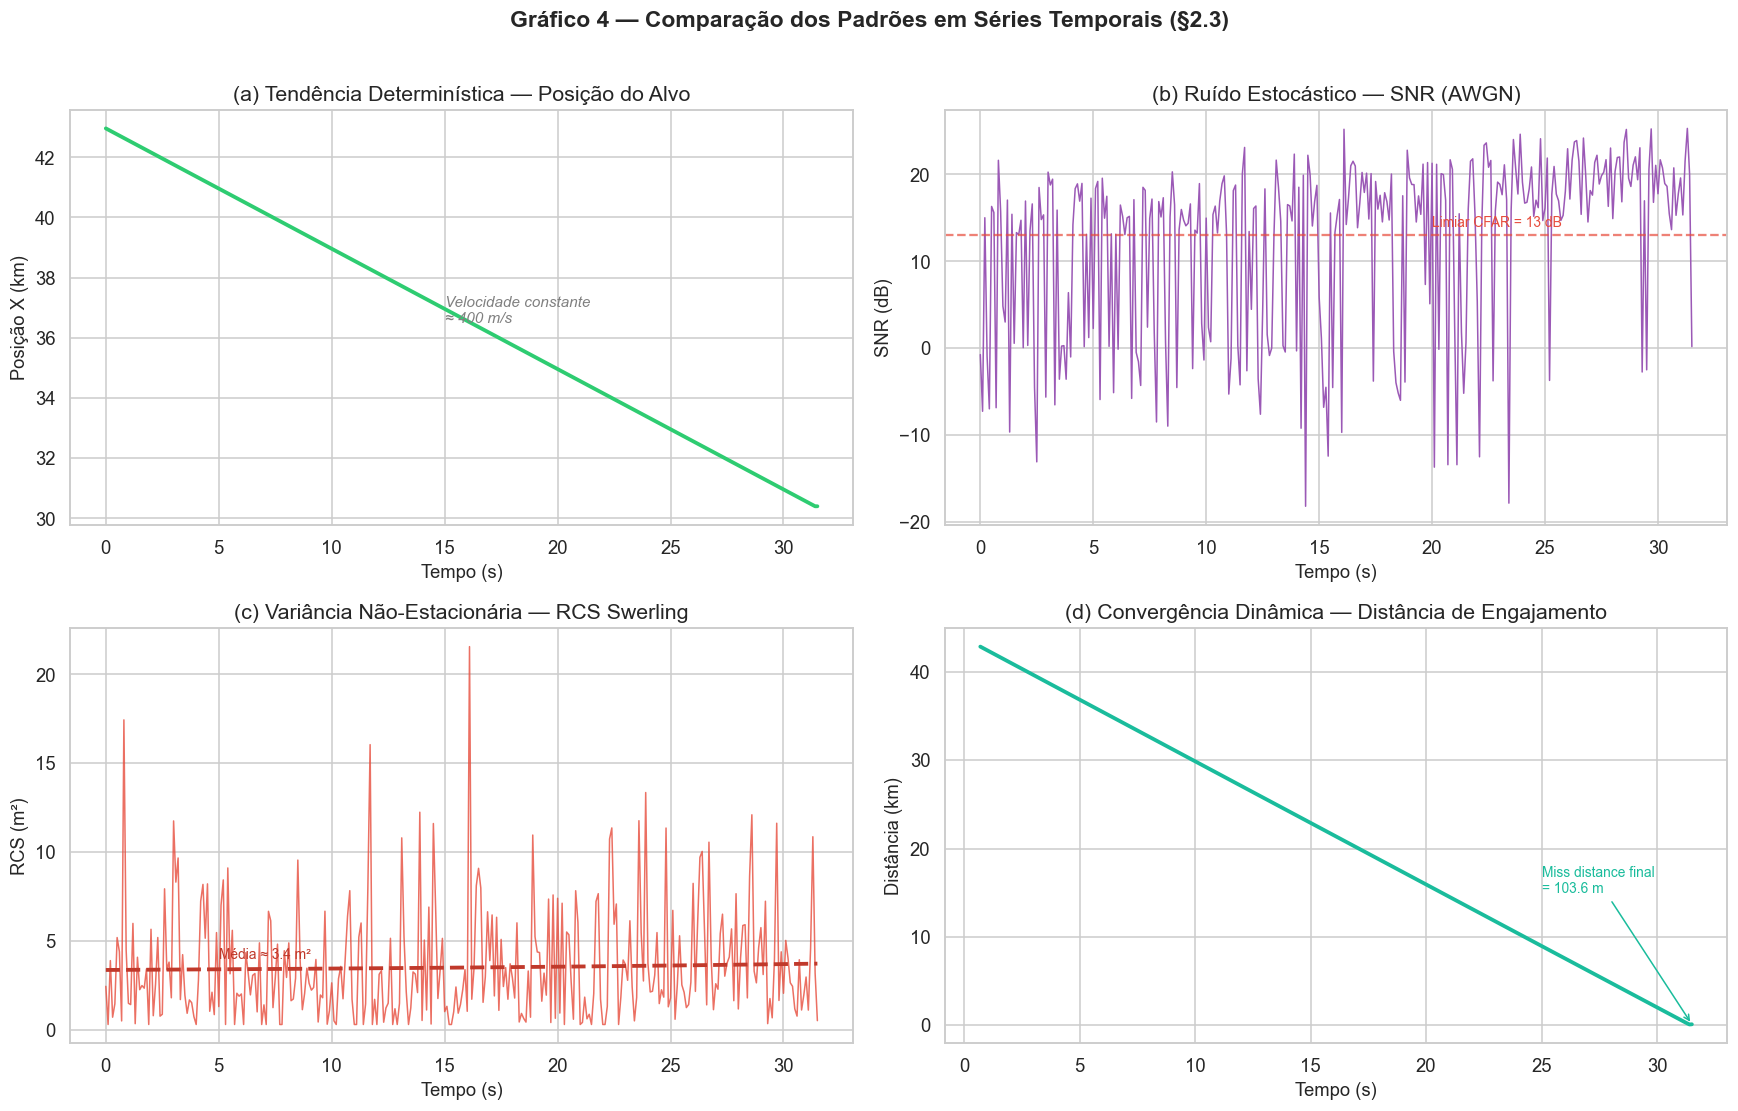

In [10]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 4 — 4 Painéis: Comparação dos Padrões Fundamentais
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Gráfico 4 — Comparação dos Padrões em Séries Temporais (§2.3)',
             fontweight='bold', fontsize=15, y=1.01)

# (a) Tendência pura
ax = axes[0, 0]
ax.plot(df['time'], df['TGT_01_pos_x'] / 1000, color=COLORS['trend'], linewidth=2.5)
ax.set_title('(a) Tendência Determinística — Posição do Alvo')
ax.set_ylabel('Posição X (km)')
ax.set_xlabel('Tempo (s)')
ax.annotate('Velocidade constante\n≈ 400 m/s', xy=(15, 36.5),
            fontsize=10, color='gray', style='italic')

# (b) Ruído estocástico
ax = axes[0, 1]
ax.plot(df['time'], df['snr_db'], color=COLORS['noise'], linewidth=1.0)
ax.axhline(y=13, color=COLORS['threshold'], linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_title('(b) Ruído Estocástico — SNR (AWGN)')
ax.set_ylabel('SNR (dB)')
ax.set_xlabel('Tempo (s)')
ax.annotate('Limiar CFAR = 13 dB', xy=(20, 14),
            fontsize=9, color=COLORS['threshold'])

# (c) Variância não-estacionária
ax = axes[1, 0]
ax.plot(df['time'], df['TGT_01_rcs_instantaneous'], color=COLORS['rcs'], linewidth=1.0, alpha=0.8)
ax.plot(df['time'], df['TGT_01_rcs_mean'], color=COLORS['rcs_mean'], linewidth=2.5, linestyle='--')
ax.set_title('(c) Variância Não-Estacionária — RCS Swerling')
ax.set_ylabel('RCS (m²)')
ax.set_xlabel('Tempo (s)')
ax.annotate('Média ≈ 3.4 m²', xy=(5, df['TGT_01_rcs_mean'].mean() + 0.5),
            fontsize=9, color=COLORS['rcs_mean'])

# (d) Convergência dinâmica
ax = axes[1, 1]
missile_active = df[df['miss_distance_m'] > 0]
ax.plot(missile_active['time'], missile_active['miss_distance_m'] / 1000,
        color=COLORS['miss'], linewidth=2.5)
ax.set_title('(d) Convergência Dinâmica — Distância de Engajamento')
ax.set_ylabel('Distância (km)')
ax.set_xlabel('Tempo (s)')
if not missile_active.empty:
    final_miss = missile_active['miss_distance_m'].iloc[-1]
    ax.annotate(f'Miss distance final\n= {final_miss:.1f} m',
                xy=(missile_active['time'].iloc[-1], final_miss / 1000),
                fontsize=9, color=COLORS['miss'],
                arrowprops=dict(arrowstyle='->', color=COLORS['miss']),
                xytext=(25, 15))

plt.tight_layout()
plt.show()

**Interpretação dos 4 painéis:**

- **(a)** Tendência perfeita. A posição do alvo é inteiramente previsível — resultado da integração numérica (RK4) com velocidade constante. Não há ruído.
- **(b)** Ruído puro. O SNR oscila erráticamente em torno de um valor médio, sem padrão discernível. Comportamento típico de AWGN.
- **(c)** Variância não-estacionária. O RCS instantâneo mostra picos esporádicos enquanto a média permanece estável. A dispersão (variância) dos picos muda ao longo do tempo.
- **(d)** Convergência não-linear. A distância de engajamento decai de forma suave mas acelerada, com a taxa de fechamento aumentando na fase terminal.

---
## §2.6 — Scatterplots (Diagramas de Dispersão)

> *"Scatterplots are a useful way to explore the relationship between two continuous variables."* — FPP3, §2.6

Enquanto o time plot mostra como **uma variável evolui no tempo**, o scatterplot mostra **como duas variáveis se relacionam entre si**, independentemente do tempo.

### Gráfico 5 — SNR vs RCS Instantâneo

A relação entre a potência do sinal recebido (SNR) e a assinatura radar (RCS) deveria, pela equação do radar, ser positiva: **quanto maior o RCS, maior o retorno**.

Mas na prática, o AWGN introduz tanta variância que a correlação fica **diluída**.

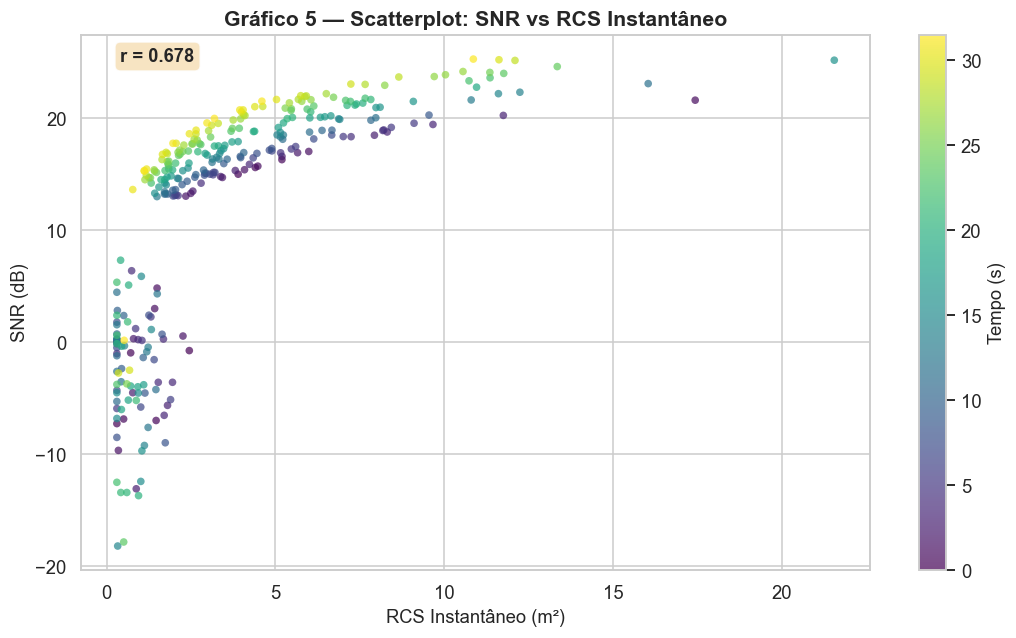

In [11]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 5 — Scatterplot: SNR vs RCS Instantâneo
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['TGT_01_rcs_instantaneous'], df['snr_db'],
                     c=df['time'], cmap='viridis', s=25, alpha=0.7, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Tempo (s)')

# Correlação
r = df['TGT_01_rcs_instantaneous'].corr(df['snr_db'])
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

ax.set_xlabel('RCS Instantâneo (m²)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Gráfico 5 — Scatterplot: SNR vs RCS Instantâneo', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 6 — Distância (Range) vs SNR

Pela **equação do radar** ($SNR \propto \frac{1}{R^4}$), o SNR deve aumentar à medida que o alvo se aproxima. Este scatterplot verifica essa relação física.

- Calculamos o **range** como a distância euclidiana entre radar e alvo.
- Esperamos ver uma **tendência crescente** no SNR conforme o range diminui.

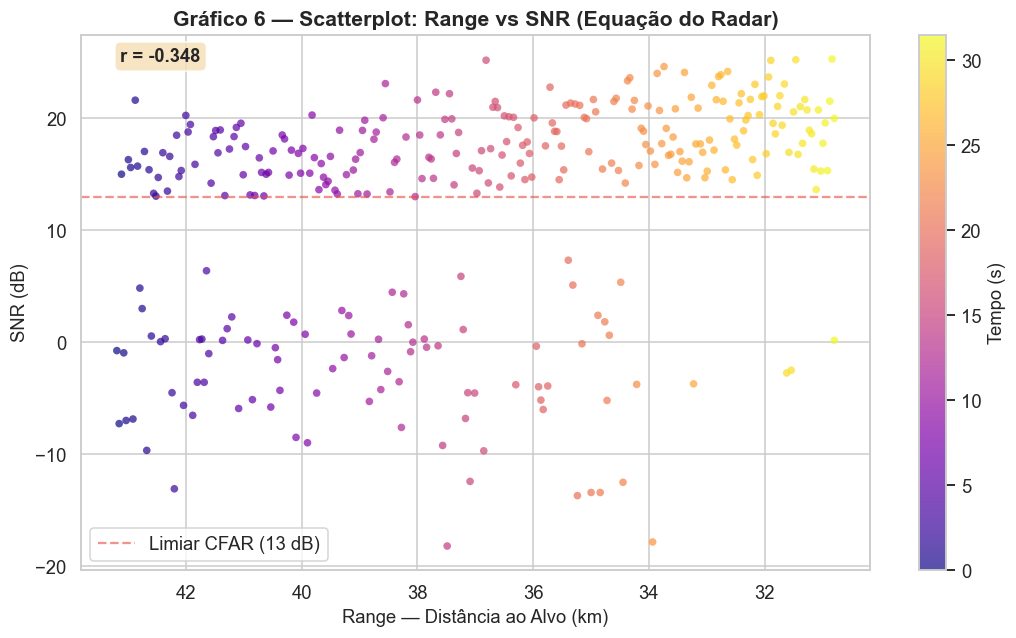

In [12]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 6 — Scatterplot: Range vs SNR
# ═══════════════════════════════════════════════════════════

# Calcular range (distância do radar na origem até o alvo)
df['range_km'] = np.sqrt(
    df['TGT_01_pos_x']**2 +
    df['TGT_01_pos_y']**2 +
    df['TGT_01_pos_z']**2
) / 1000

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['range_km'], df['snr_db'],
                     c=df['time'], cmap='plasma', s=25, alpha=0.7, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Tempo (s)')

ax.axhline(y=13, color=COLORS['threshold'], linestyle='--', linewidth=1.5,
           alpha=0.6, label='Limiar CFAR (13 dB)')

# Correlação
r = df['range_km'].corr(df['snr_db'])
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Range — Distância ao Alvo (km)')
ax.set_ylabel('SNR (dB)')
ax.set_title('Gráfico 6 — Scatterplot: Range vs SNR (Equação do Radar)', fontweight='bold')
ax.legend()
ax.invert_xaxis()  # Inverter para mostrar aproximação da esquerda para direita
plt.tight_layout()
plt.show()

### Gráfico 7 — Distância de Engajamento vs G-Force

A guiagem proporcional (PN - Proportional Navigation) causa uma **relação não-linear** entre distância e aceleração:
- A grandes distâncias, o míssil requer pouca correção → G baixo.
- Na fase terminal, pequenos erros angulares amplificam → **G cresce exponencialmente**.

Este gráfico demonstra que o coeficiente de correlação *r* pode ser enganoso para relações não-lineares (§2.6, FPP3).

C:\Users\rw17\AppData\Local\Temp\ipykernel_45028\2492216878.py:28: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rw17\AppData\Local\Temp\ipykernel_45028\2492216878.py:28: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\rw17\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rw17\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


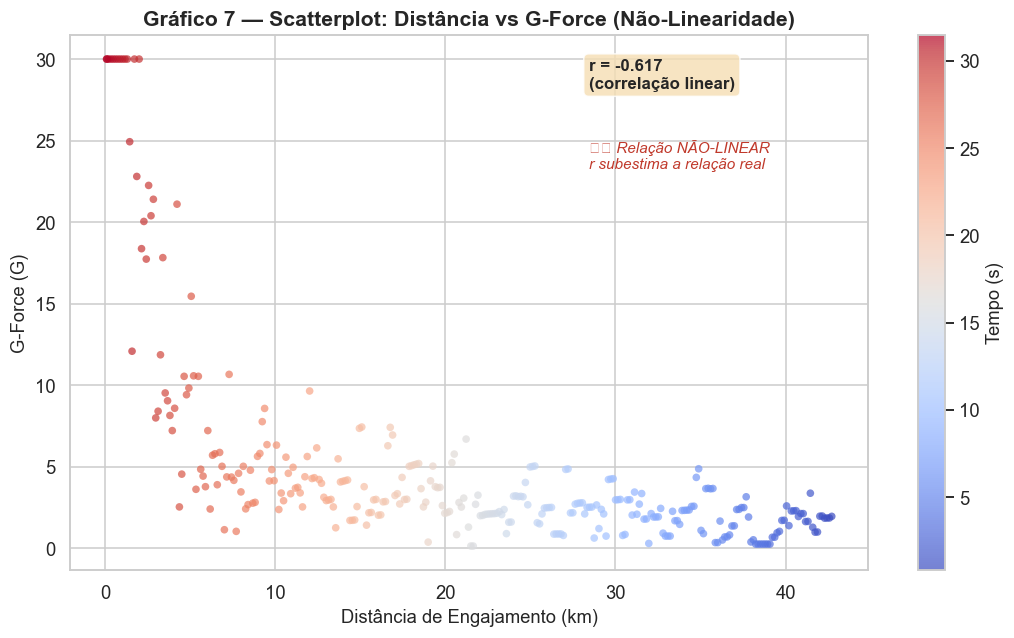

In [13]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 7 — Scatterplot: Miss Distance vs G-Force
# ═══════════════════════════════════════════════════════════

active = df[(df['missile_launched'] == True) & (df['g_force'] > 0)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(active['miss_distance_m'] / 1000, active['g_force'],
                     c=active['time'], cmap='coolwarm', s=25, alpha=0.7, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Tempo (s)')

# Correlação
r = active['miss_distance_m'].corr(active['g_force'])
ax.annotate(f'r = {r:.3f}\n(correlação linear)',
            xy=(0.65, 0.90), xycoords='axes fraction',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))
ax.annotate('⚠️ Relação NÃO-LINEAR\nr subestima a relação real',
            xy=(0.65, 0.75), xycoords='axes fraction',
            fontsize=10, color='#c0392b', style='italic')

ax.set_xlabel('Distância de Engajamento (km)')
ax.set_ylabel('G-Force (G)')
ax.set_title('Gráfico 7 — Scatterplot: Distância vs G-Force (Não-Linearidade)', fontweight='bold')
plt.tight_layout()
plt.show()

### Gráfico 8 — Matriz de Scatterplots (Correlações Múltiplas)

> *"When there are several potential predictor variables, it is useful to plot each variable against each other variable."* — FPP3, §2.6

A **matriz de scatterplots** permite visualizar todas as correlações par a par simultaneamente.
A diagonal mostra a distribuição de cada variável (KDE), e os triângulos superior/inferior mostram os scatterplots.

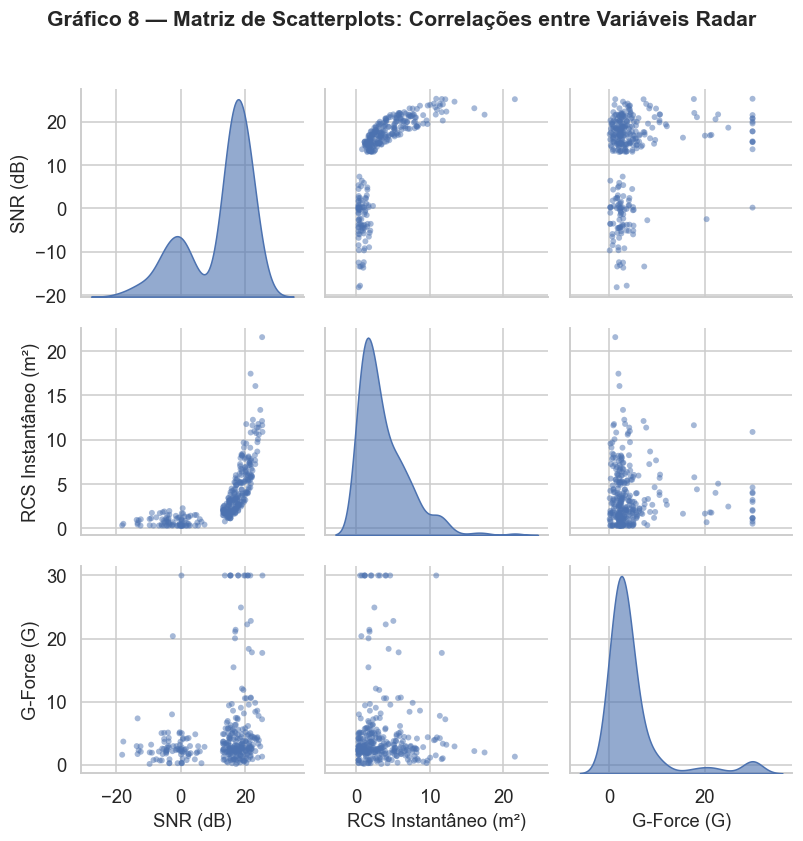


📊 Matriz de Correlação de Pearson:
                      SNR (dB)  RCS Instantâneo (m²)  G-Force (G)
SNR (dB)                 1.000                 0.675        0.200
RCS Instantâneo (m²)     0.675                 1.000       -0.051
G-Force (G)              0.200                -0.051        1.000


In [14]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 8 — Matriz de Scatterplots (Pairplot)
# ═══════════════════════════════════════════════════════════

cols_pair = ['snr_db', 'TGT_01_rcs_instantaneous', 'g_force']

# Filtrar apenas dados com míssil ativo e g_force > 0
df_pair = df[(df['missile_launched'] == True) & (df['g_force'] > 0)][cols_pair].copy()
df_pair.columns = ['SNR (dB)', 'RCS Instantâneo (m²)', 'G-Force (G)']

g = sns.pairplot(df_pair, diag_kind='kde', corner=False,
                 plot_kws={'alpha': 0.5, 's': 15, 'edgecolors': 'none'},
                 diag_kws={'fill': True, 'alpha': 0.6})

g.figure.suptitle('Gráfico 8 — Matriz de Scatterplots: Correlações entre Variáveis Radar',
                  fontweight='bold', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

# Tabela de correlação
print('\n📊 Matriz de Correlação de Pearson:')
print(df_pair.corr().round(3).to_string())

---
## §2.7 — Lag Plots (Gráficos de Defasagem)

> *"A lag plot is a scatterplot of $y_t$ against $y_{t-k}$ for different values of $k$."* — FPP3, §2.7

Os lag plots revelam **autocorrelação** de forma visual:
- Se o lag plot mostra um **padrão linear** → existe autocorrelação forte naquele lag.
- Se o lag plot é uma **nuvem dispersa** → não há autocorrelação → comportamento de ruído branco.

Analisaremos duas séries com comportamentos opostos:
1. **SNR** — esperamos dispersão (ruído AWGN, sem memória).
2. **RCS Instantâneo** — cintilação Swerling, comportamento quase i.i.d.

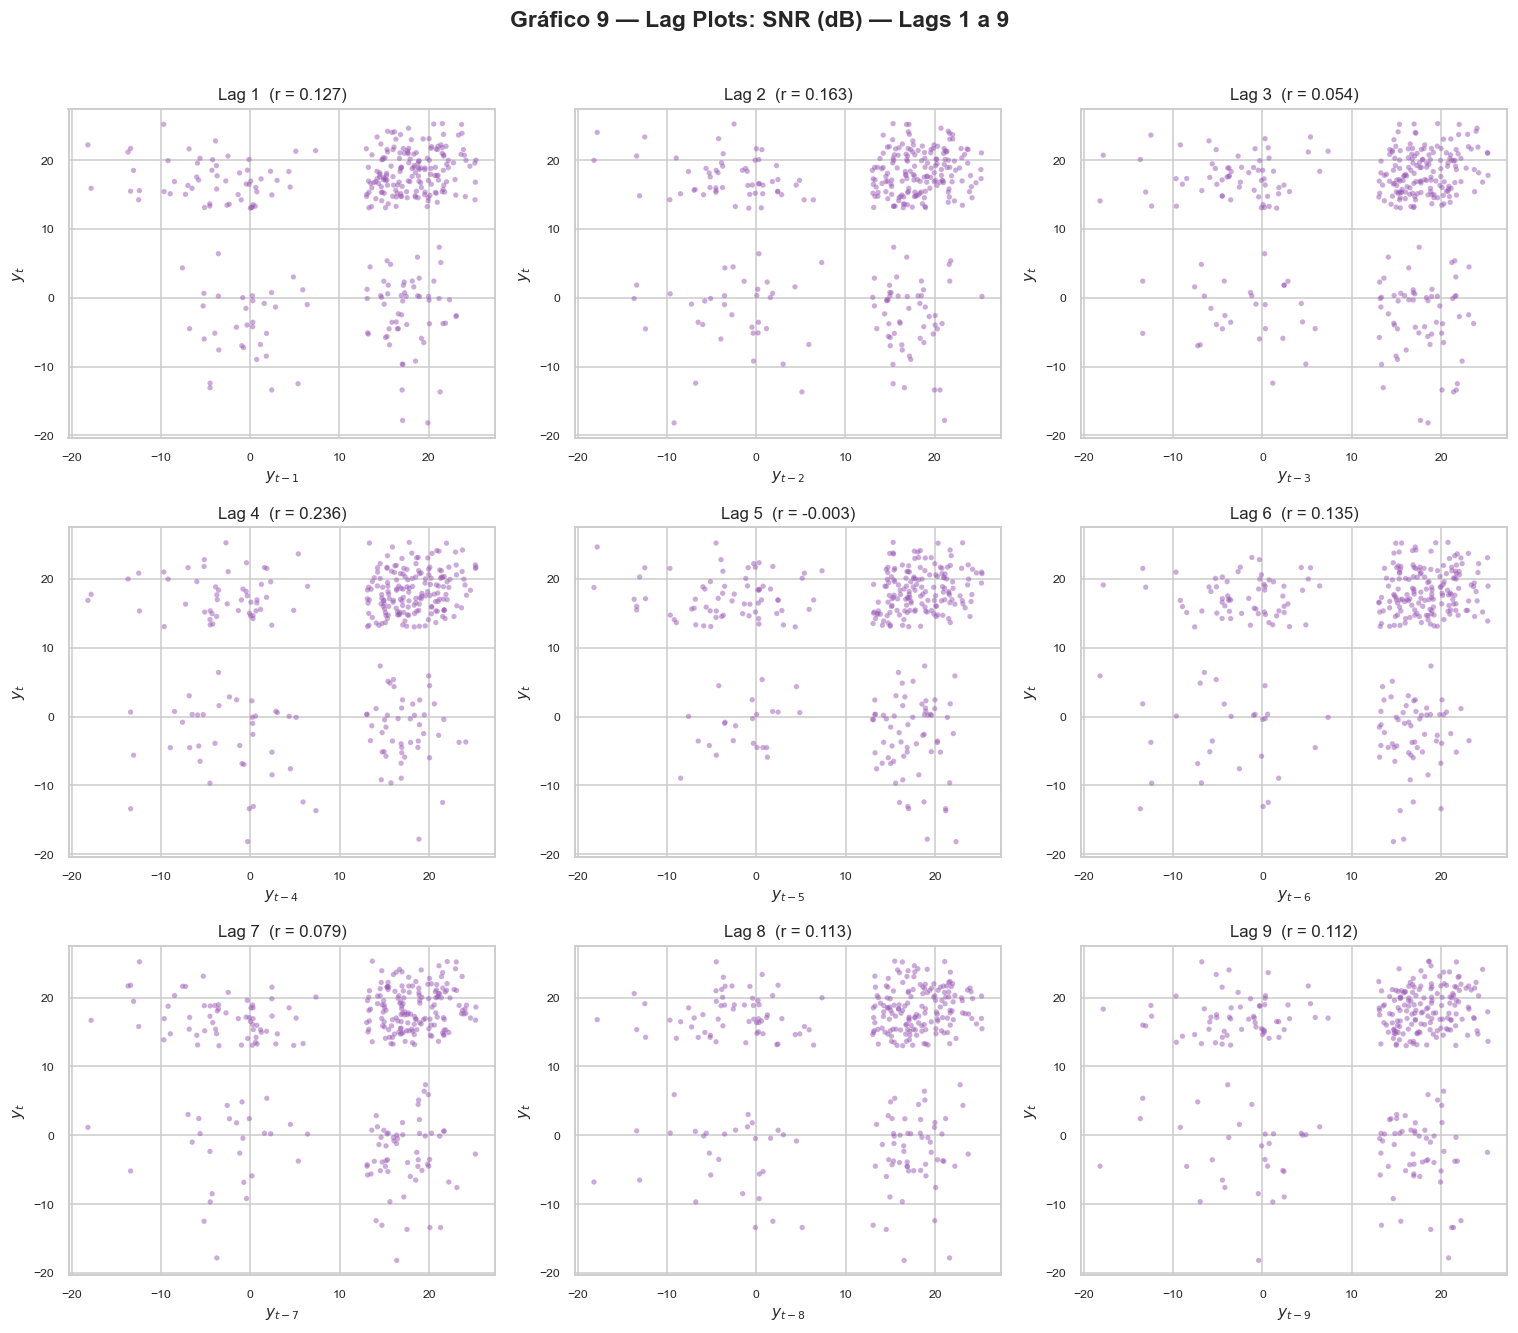

In [15]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 9 — Lag Plot: SNR (lags 1–9)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Gráfico 9 — Lag Plots: SNR (dB) — Lags 1 a 9',
             fontweight='bold', fontsize=15, y=1.01)

snr = df['snr_db'].values

for i, ax in enumerate(axes.flat):
    k = i + 1
    y = snr[k:]
    y_lag = snr[:-k]

    ax.scatter(y_lag, y, s=12, alpha=0.5, color=COLORS['noise'], edgecolors='none')

    # Calcular correlação
    r = np.corrcoef(y_lag, y)[0, 1]
    ax.set_title(f'Lag {k}  (r = {r:.3f})', fontsize=11)
    ax.set_xlabel(f'$y_{{t-{k}}}$', fontsize=10)
    ax.set_ylabel(f'$y_t$', fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**Interpretação (SNR):** Todos os lag plots mostram uma **nuvem dispersa sem padrão** — nenhuma relação linear entre $y_t$ e $y_{t-k}$. Isto confirma que o SNR se comporta como **ruído branco**: cada observação é independente das anteriores.

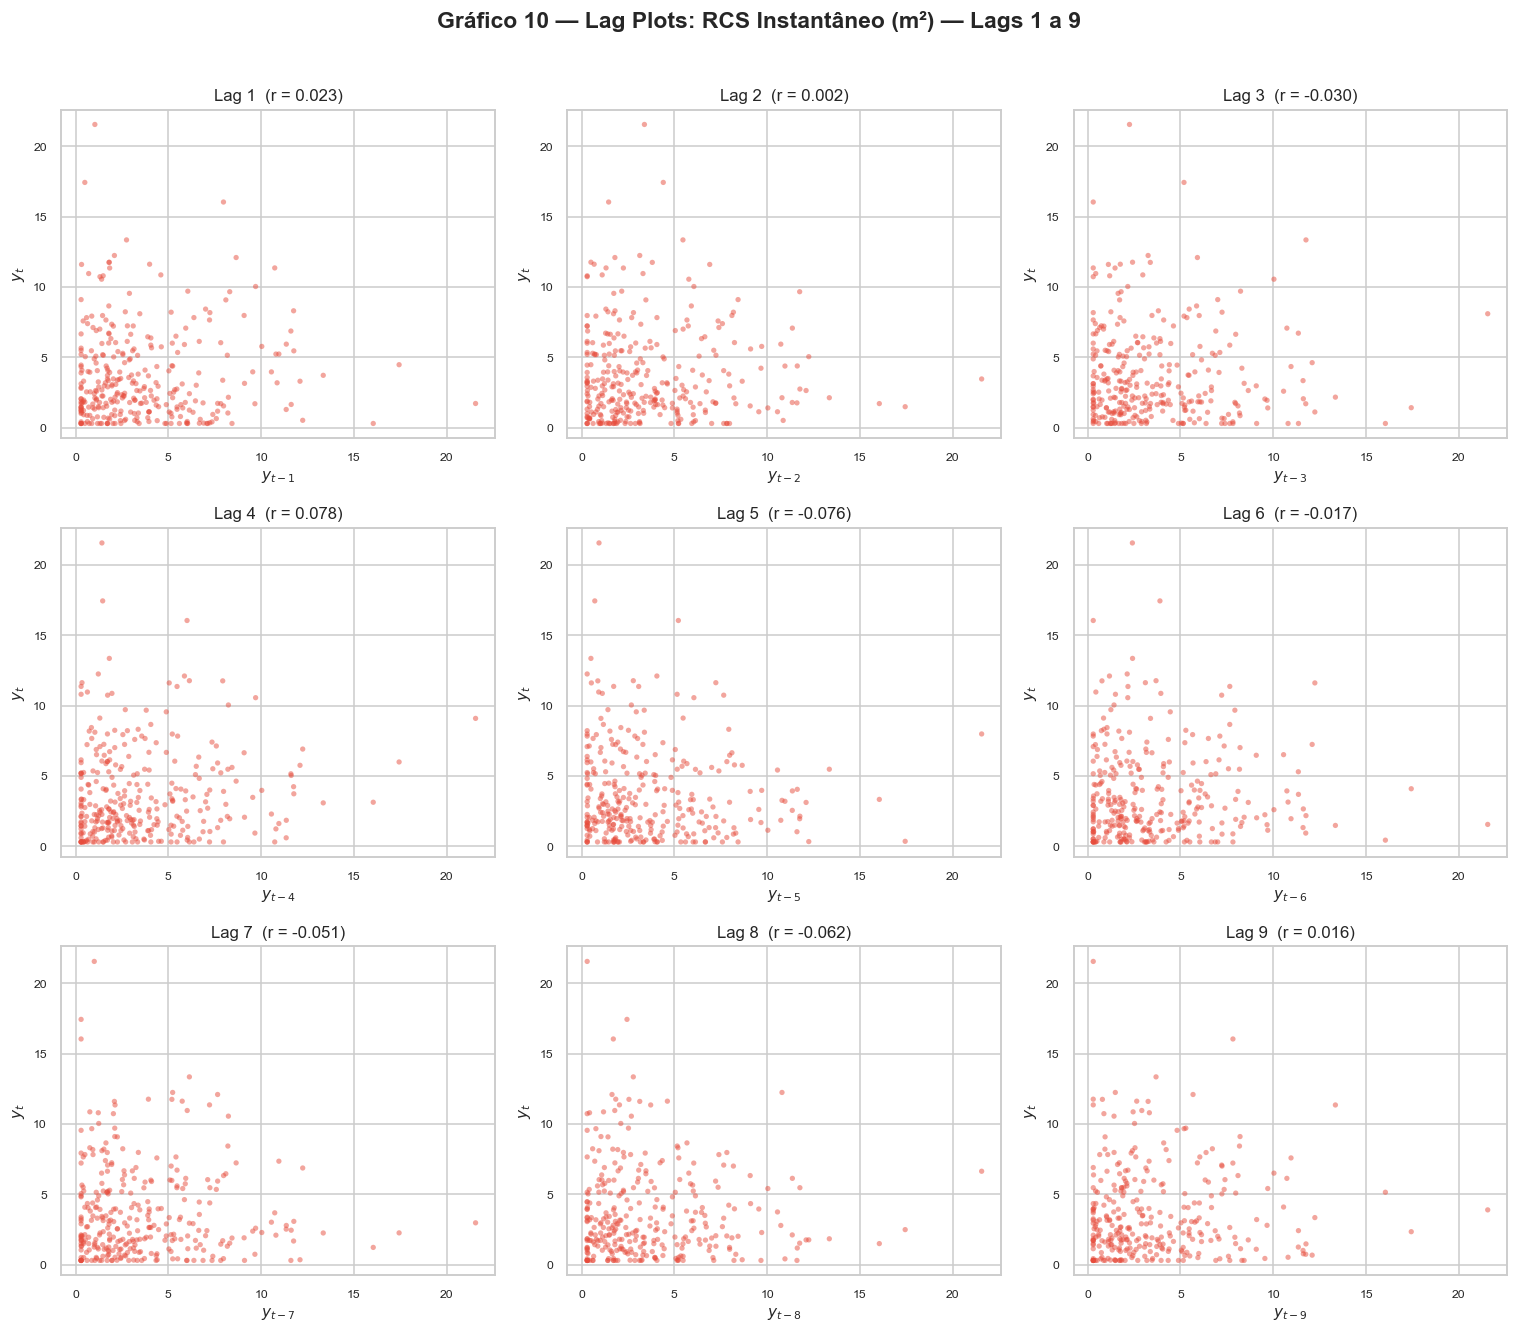

In [16]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 10 — Lag Plot: RCS Instantâneo (lags 1–9)
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Gráfico 10 — Lag Plots: RCS Instantâneo (m²) — Lags 1 a 9',
             fontweight='bold', fontsize=15, y=1.01)

rcs = df['TGT_01_rcs_instantaneous'].values

for i, ax in enumerate(axes.flat):
    k = i + 1
    y = rcs[k:]
    y_lag = rcs[:-k]

    ax.scatter(y_lag, y, s=12, alpha=0.5, color=COLORS['rcs'], edgecolors='none')

    r = np.corrcoef(y_lag, y)[0, 1]
    ax.set_title(f'Lag {k}  (r = {r:.3f})', fontsize=11)
    ax.set_xlabel(f'$y_{{t-{k}}}$', fontsize=10)
    ax.set_ylabel(f'$y_t$', fontsize=10)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**Interpretação (RCS):** O RCS instantâneo também mostra **dispersão sem padrão claro** em todos os lags, confirmando que a cintilação Swerling gera valores aproximadamente **independentes e identicamente distribuídos (i.i.d.)** — consistente com o modelo teórico Swerling Case I.

---
## §2.8 — Autocorrelação (ACF)

> *"The autocorrelation coefficients measure the linear relationship between lagged values of a time series."* — FPP3, §2.8

O **ACF** (Autocorrelation Function) é o diagnóstico formal do que observamos visualmente nos lag plots.

$$r_k = \frac{\sum_{t=k+1}^{T}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}$$

- As **linhas pontilhadas azuis** representam os limites de significância: $\pm 1.96 / \sqrt{T}$
- Barras que **ultrapassam** os limites indicam autocorrelação **estatisticamente significativa**.

Para $T = 317$ amostras: limites $= \pm 1.96 / \sqrt{317} \approx \pm 0.110$

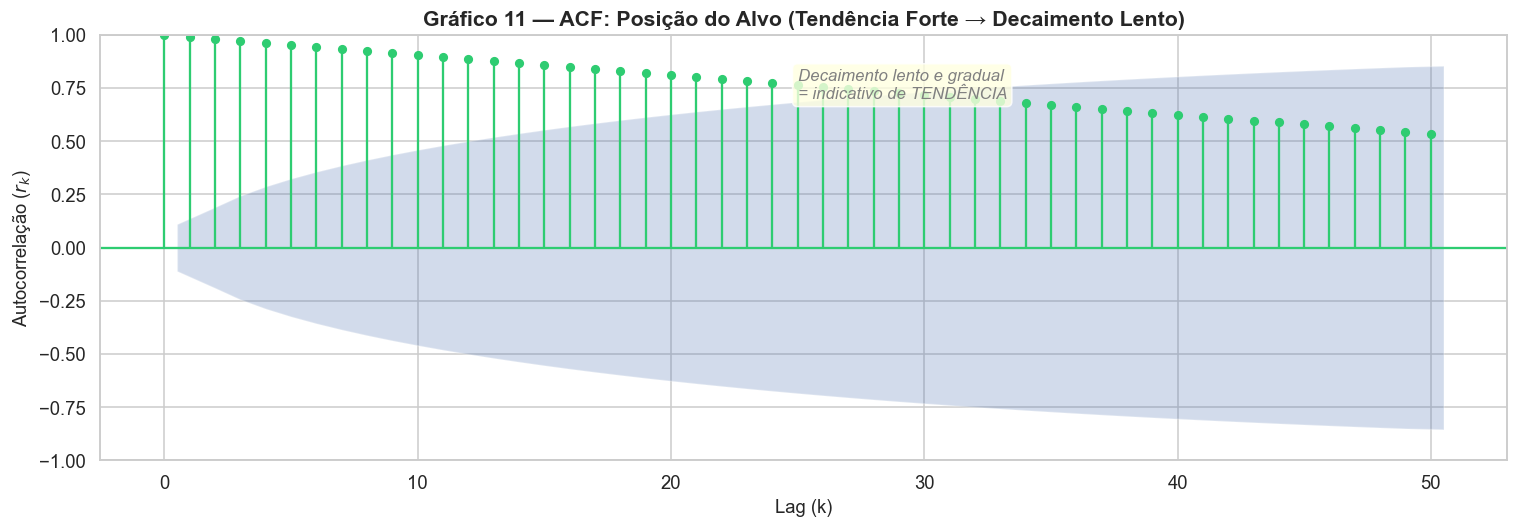

In [17]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 11 — ACF da Posição do Alvo (Tendência Forte)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

nlags = 50
plot_acf(df['TGT_01_pos_x'], lags=nlags, ax=ax,
         color=COLORS['trend'], vlines_kwargs={'colors': COLORS['trend']},
         title='')

ax.set_title('Gráfico 11 — ACF: Posição do Alvo (Tendência Forte → Decaimento Lento)',
             fontweight='bold')
ax.set_xlabel('Lag (k)')
ax.set_ylabel('Autocorrelação ($r_k$)')

ax.annotate('Decaimento lento e gradual\n= indicativo de TENDÊNCIA',
            xy=(25, 0.7), fontsize=11, color='gray', style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

**Interpretação:** O ACF da posição mostra um **decaimento extremamente lento** — todas as autocorrelações são próximas de 1.0 e permanecem fortemente positivas até lags altos. Este é o padrão clássico descrito no FPP3 para séries com **forte tendência linear** (§2.8).

> *"When data have a trend, the autocorrelations for small lags tend to be large and positive because observations nearby in time are also nearby in size."* — FPP3

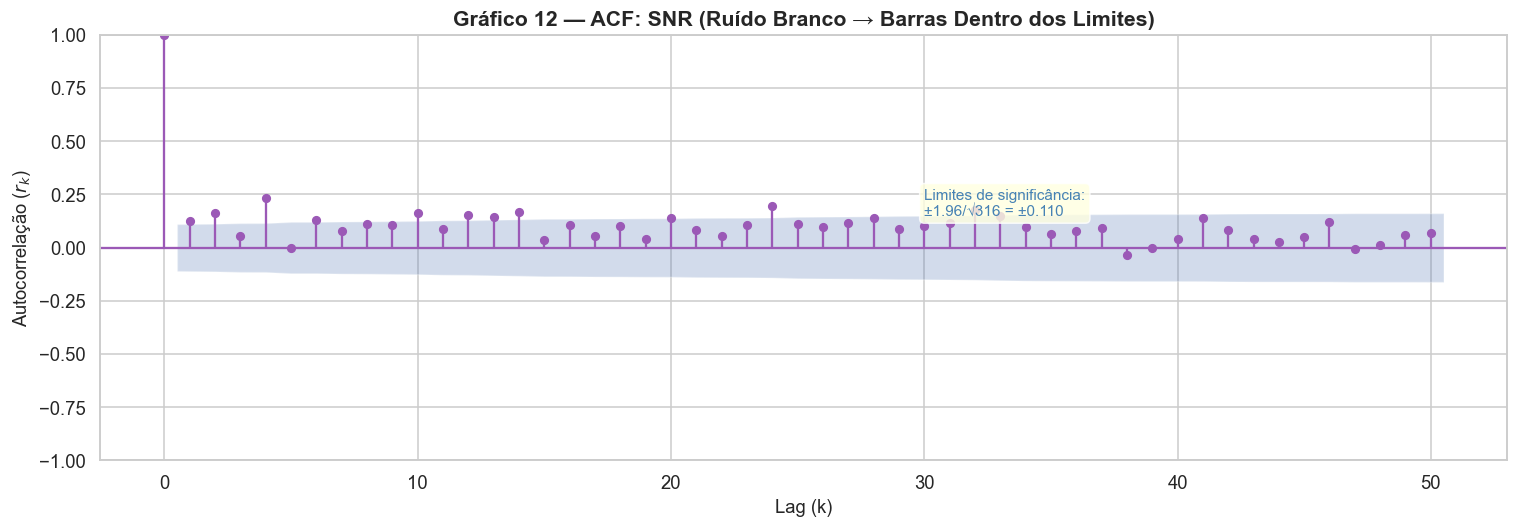


📊 Verificação de Ruído Branco (SNR):
   Barras significativas fora dos limites: 17/50 (34.0%)
   Esperado para ruído branco (5%): 2 barras
   ⚠️ Possível autocorrelação residual


In [18]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 12 — ACF do SNR (Esperamos Ruído Branco)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(df['snr_db'], lags=nlags, ax=ax,
         color=COLORS['noise'], vlines_kwargs={'colors': COLORS['noise']},
         title='')

ax.set_title('Gráfico 12 — ACF: SNR (Ruído Branco → Barras Dentro dos Limites)',
             fontweight='bold')
ax.set_xlabel('Lag (k)')
ax.set_ylabel('Autocorrelação ($r_k$)')

T = len(df)
limit = 1.96 / np.sqrt(T)
ax.annotate(f'Limites de significância:\n±1.96/√{T} = ±{limit:.3f}',
            xy=(30, 0.15), fontsize=10, color='steelblue',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Verificação numérica
acf_values = acf(df['snr_db'], nlags=nlags, fft=True)
n_significant = np.sum(np.abs(acf_values[1:]) > limit)  # excluir lag 0
pct_significant = n_significant / nlags * 100
print(f'\n📊 Verificação de Ruído Branco (SNR):')
print(f'   Barras significativas fora dos limites: {n_significant}/{nlags} ({pct_significant:.1f}%)')
print(f'   Esperado para ruído branco (5%): {0.05 * nlags:.0f} barras')
if pct_significant <= 10:
    print(f'   ✅ Consistente com RUÍDO BRANCO')
else:
    print(f'   ⚠️ Possível autocorrelação residual')

---
## §2.9 — Ruído Branco (White Noise)

> *"Time series that show no autocorrelation are called white noise."* — FPP3, §2.9

Uma série é **ruído branco** se:
1. A média é constante (ou zero).
2. A variância é constante.
3. **Todas** as autocorrelações $r_k \approx 0$ (dentro dos limites $\pm 1.96/\sqrt{T}$).

Para confirmar, analisamos o ACF do **RCS instantâneo** — a cintilação Swerling deveria se comportar como ruído branco em torno da média.

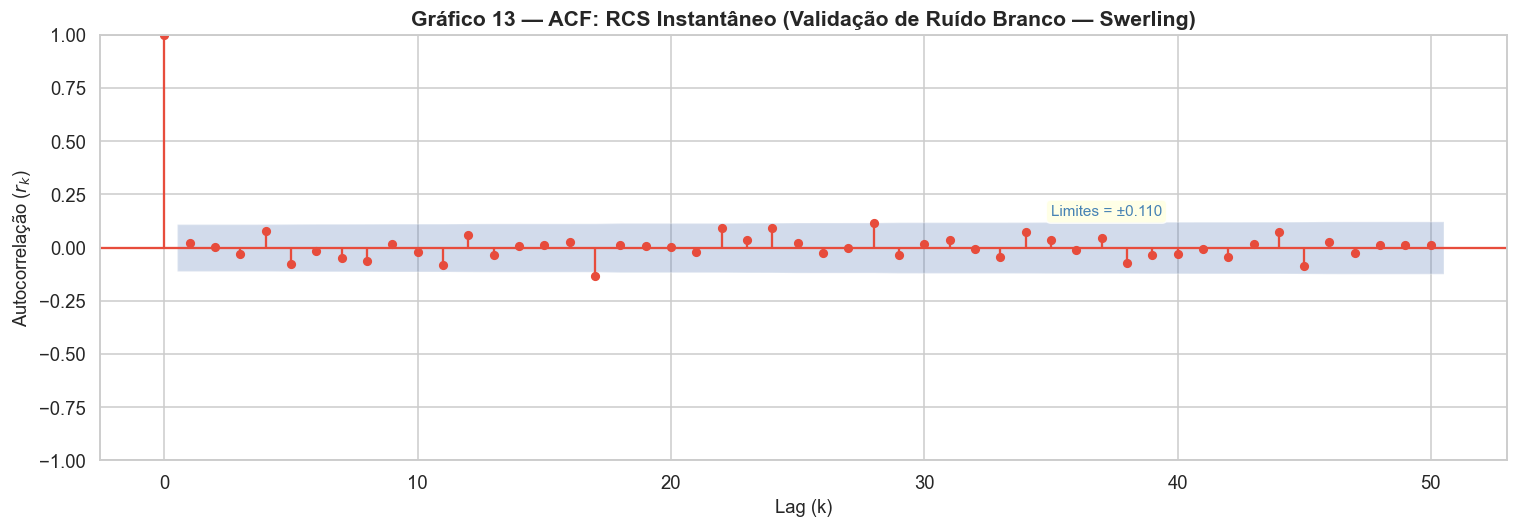


📊 Verificação de Ruído Branco (RCS instantâneo):
   Barras significativas fora dos limites: 2/50 (4.0%)
   Esperado para ruído branco (5%): 2 barras
   ✅ Consistente com RUÍDO BRANCO (Swerling Case I confirmado)


In [19]:
# ═══════════════════════════════════════════════════════════
# GRÁFICO 13 — ACF do RCS Instantâneo (Teste de White Noise)
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(df['TGT_01_rcs_instantaneous'], lags=nlags, ax=ax,
         color=COLORS['rcs'], vlines_kwargs={'colors': COLORS['rcs']},
         title='')

ax.set_title('Gráfico 13 — ACF: RCS Instantâneo (Validação de Ruído Branco — Swerling)',
             fontweight='bold')
ax.set_xlabel('Lag (k)')
ax.set_ylabel('Autocorrelação ($r_k$)')

ax.annotate(f'Limites = ±{limit:.3f}',
            xy=(35, 0.15), fontsize=10, color='steelblue',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Verificação numérica
acf_rcs = acf(df['TGT_01_rcs_instantaneous'], nlags=nlags, fft=True)
n_significant_rcs = np.sum(np.abs(acf_rcs[1:]) > limit)
pct_rcs = n_significant_rcs / nlags * 100
print(f'\n📊 Verificação de Ruído Branco (RCS instantâneo):')
print(f'   Barras significativas fora dos limites: {n_significant_rcs}/{nlags} ({pct_rcs:.1f}%)')
print(f'   Esperado para ruído branco (5%): {0.05 * nlags:.0f} barras')
if pct_rcs <= 10:
    print(f'   ✅ Consistente com RUÍDO BRANCO (Swerling Case I confirmado)')
else:
    print(f'   ⚠️ Possível dependência temporal residual (considerar Swerling Case III/IV)')

---
## Resumo: O que Cada Gráfico Revelou

| # | Gráfico | Seção FPP3 | Conclusão Principal |
|---|---------|-----------|---------------------|
| 1 | Time Plot — Posição | §2.2 | **Tendência linear perfeita** (v ≈ 400 m/s) |
| 2 | Time Plot — SNR | §2.2 | **Série ruidosa** (AWGN), oscilando em torno do CFAR |
| 3 | Time Plot — RCS | §2.2 | **Variância não-estacionária** com média estável |
| 4 | 4 Painéis | §2.3 | Tendência, ruído, variância e convergência são visualmente distintos |
| 5 | Scatter: SNR × RCS | §2.6 | Correlação fraca — AWGN domina a relação |
| 6 | Scatter: Range × SNR | §2.6 | Tendência positiva confirmando equação do radar |
| 7 | Scatter: Dist × G-Force | §2.6 | **Relação não-linear** — *r* subestima a dependência |
| 8 | Matriz Pairplot | §2.6 | Visão panorâmica das correlações cruzadas |
| 9 | Lag Plot — SNR | §2.7 | Nuvem dispersa → **sem autocorrelação** |
| 10 | Lag Plot — RCS | §2.7 | Nuvem dispersa → **i.i.d.** (Swerling Case I) |
| 11 | ACF — Posição | §2.8 | Decaimento lento → **tendência forte** |
| 12 | ACF — SNR | §2.8/§2.9 | Barras dentro dos limites → **ruído branco (AWGN)** |
| 13 | ACF — RCS | §2.9 | Validação: cintilação Swerling ≈ **white noise** |

### Conclusões-Chave

1. **Visualização antes de modelagem** — Os gráficos temporais revelam imediatamente se há tendência, ruído ou padrões.
2. **Correlação ≠ Causalidade** — O scatterplot SNR × RCS mostra que, apesar de uma relação física real (equação do radar), o *r* linear é baixo.
3. **Cuidado com *r* em relações não-lineares** — A relação Distância × G-Force é forte mas o *r* de Pearson não a captura adequadamente.
4. **ACF como diagnóstico** — Tendência produz decaimento lento; ruído branco mantém tudo dentro dos limites de significância.
5. **Ruído branco é o objetivo final** — Os resíduos de um bom modelo devem parecer ruído branco, exatamente como nosso SNR.

---
### Referências

- Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. OTexts. [otexts.com/fpp3](https://otexts.com/fpp3/)
- Capítulo 2: [Time Series Graphics](https://otexts.com/fpp3/graphics.html)
- Simulador: [Glaukopis — rafaelwilliamm/glaukopis](https://github.com/rafaelwilliamm/glaukopis)